In [1]:
# ==========================================================
# TASK 3 : Visualization & Analysis
# Import Required Libraries
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

# Better looking plots
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully")

ModuleNotFoundError: No module named 'wordcloud'

In [2]:
import sys

print(sys.executable)

c:\ProgramData\anaconda3\python.exe


In [3]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
from wordcloud import WordCloud

print("WordCloud installed successfully!")

ModuleNotFoundError: No module named 'wordcloud'

In [6]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
from wordcloud import WordCloud

print("WordCloud installed successfully!")

WordCloud installed successfully!


In [2]:
# ==========================================================
# TASK 3 : Visualization & Analysis
# Import Required Libraries
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

# Better looking plots
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ==========================================================
# Load Cleaned Dataset
# ==========================================================

df = pd.read_csv("../data/books_cleaned.csv")

print(df.shape)

df.head()

(100, 15)


,Title,Category,Price,Rating,Availability,Product Description,UPC,Number of Reviews,Product URL,Available Stock,description_word_count,price_band,affordability_score,value_score,recommended
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available)\n \n\n \n \n ...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,Premium,0.223,0.45,No
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available)\n \n\n \n \n ...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,Luxury,0.117,0.23,No
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available)\n \n\n \n \n ...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,Premium,0.353,0.35,No
3,Olio,Poetry,23.88,1,In stock (19 available)\n \n\n \n \n ...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Economy,0.589,0.59,No
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available)\n \n\n \n \n ...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,Luxury,0.015,0.04,No


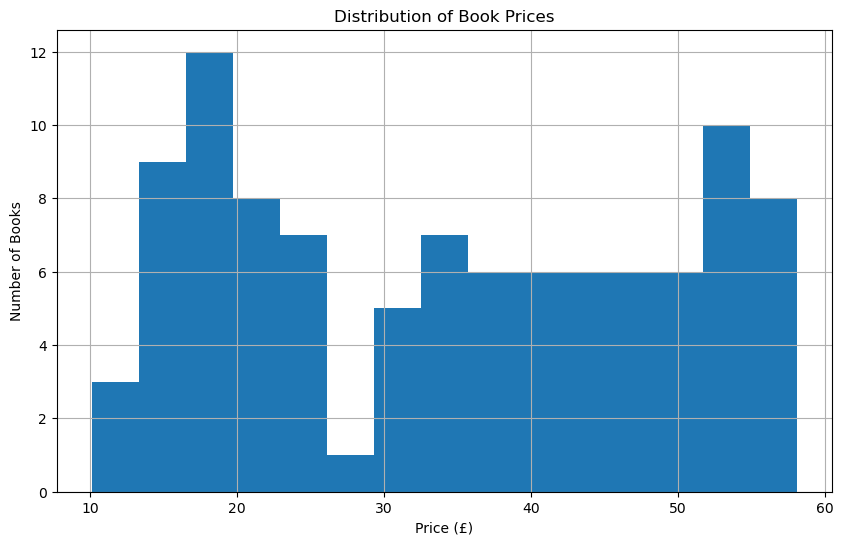

In [4]:
# ==========================================================
# Graph 1 : Price Distribution
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(df["Price"], bins=15)

plt.title("Distribution of Book Prices")

plt.xlabel("Price (£)")

plt.ylabel("Number of Books")

plt.grid(True)

plt.show()

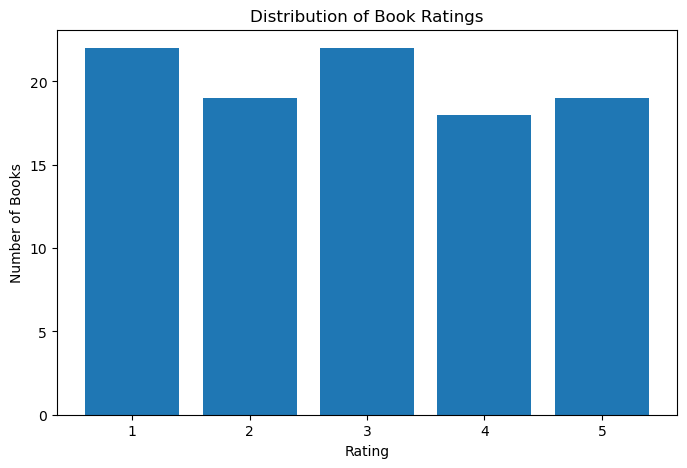

In [5]:
# ==========================================================
# Graph 2 : Rating Distribution
# ==========================================================

rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(rating_counts.index.astype(str), rating_counts.values)

plt.title("Distribution of Book Ratings")

plt.xlabel("Rating")

plt.ylabel("Number of Books")

plt.show()

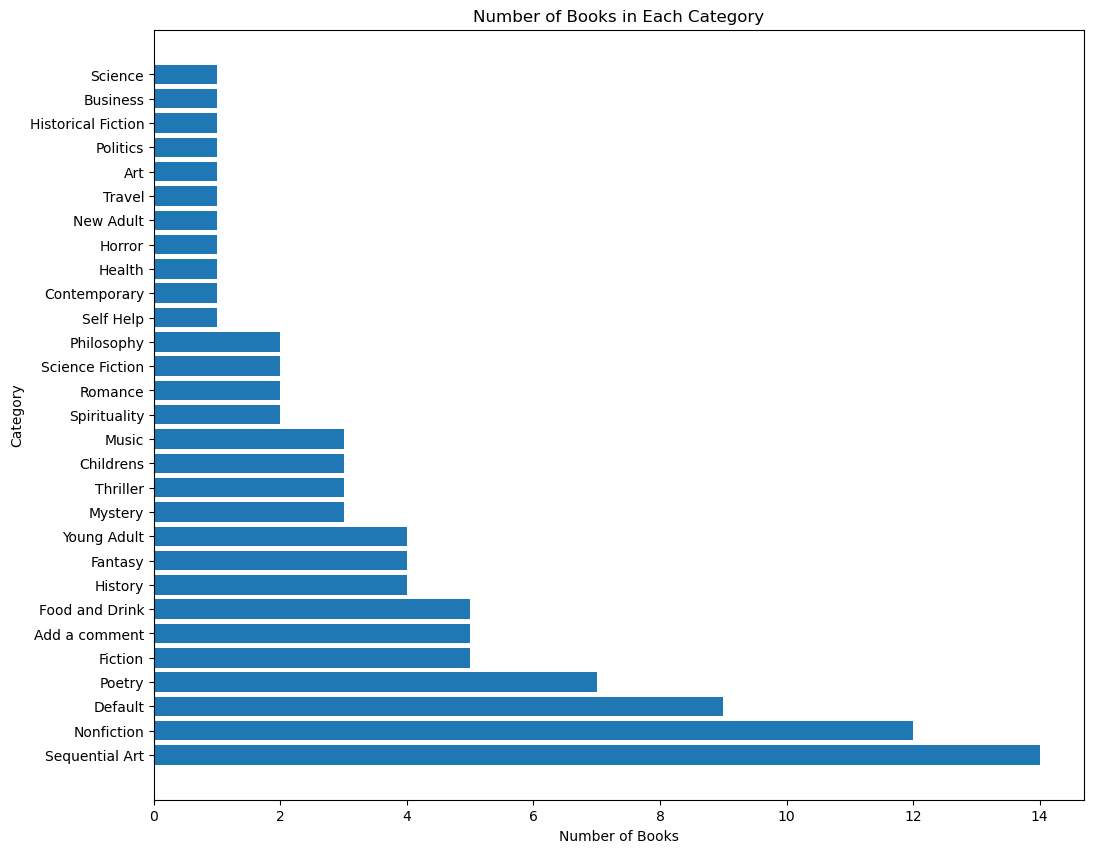

In [6]:
# ==========================================================
# Graph 3 : Number of Books by Category
# ==========================================================

category_counts = df["Category"].value_counts()

plt.figure(figsize=(12,10))

plt.barh(category_counts.index, category_counts.values)

plt.title("Number of Books in Each Category")

plt.xlabel("Number of Books")

plt.ylabel("Category")

plt.show()

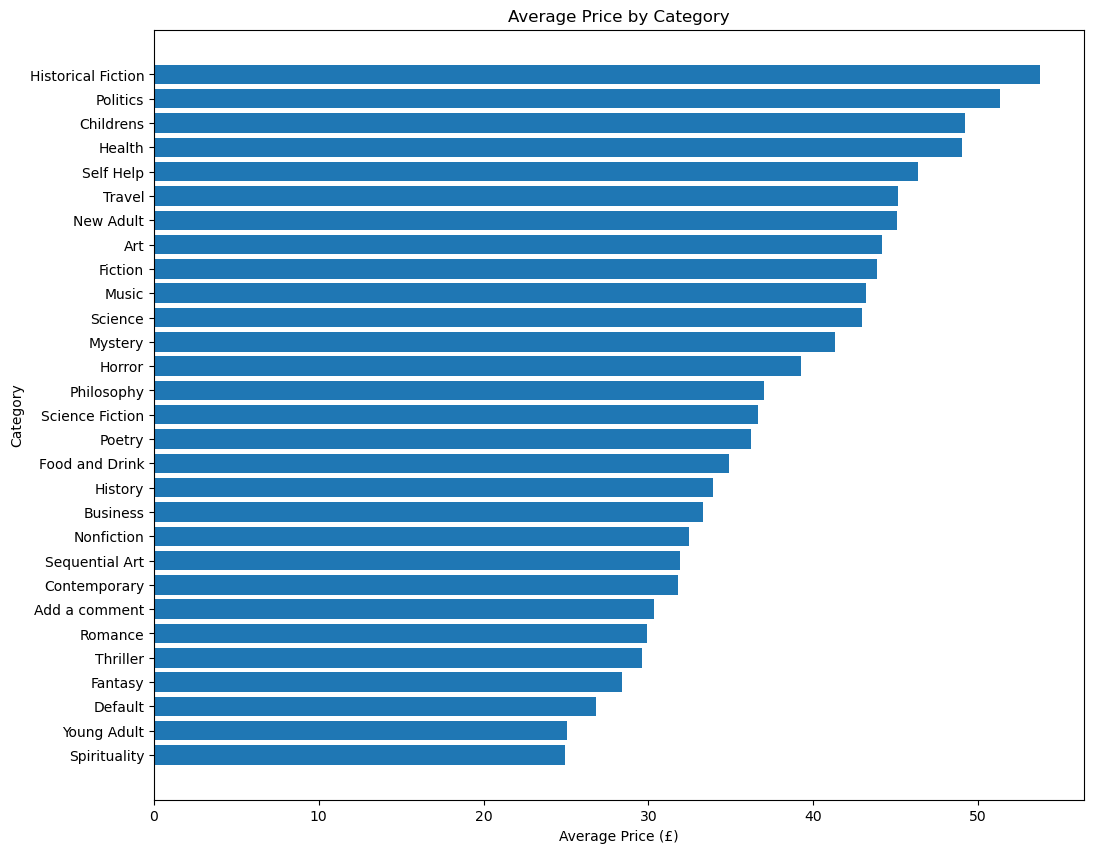

In [7]:
# ==========================================================
# Graph 4 : Average Price by Category
# ==========================================================

avg_price = (
    df.groupby("Category")["Price"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,10))

plt.barh(avg_price.index, avg_price.values)

plt.title("Average Price by Category")

plt.xlabel("Average Price (£)")

plt.ylabel("Category")

plt.show()

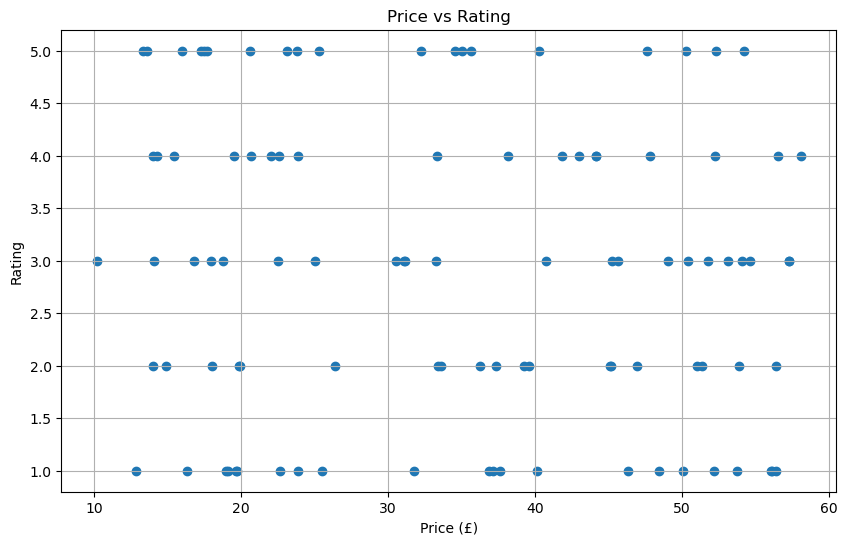

In [8]:
# ==========================================================
# Graph 5 : Price vs Rating
# ==========================================================

plt.figure(figsize=(10,6))

plt.scatter(df["Price"], df["Rating"])

plt.title("Price vs Rating")

plt.xlabel("Price (£)")

plt.ylabel("Rating")

plt.grid(True)

plt.show()

<Figure size 1500x800 with 0 Axes>

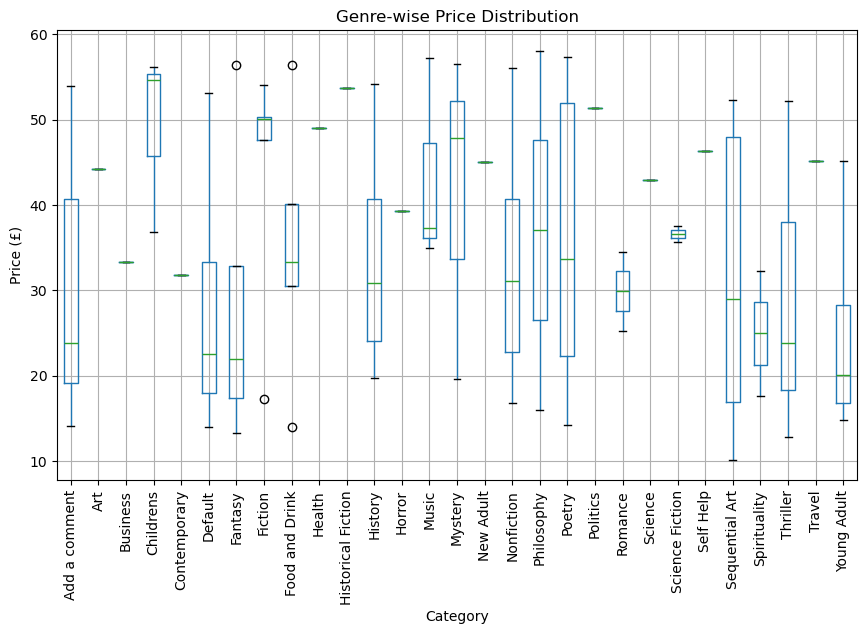

In [9]:
# ==========================================================
# Graph 6 : Genre-wise Price Distribution
# ==========================================================

plt.figure(figsize=(15,8))

df.boxplot(
    column="Price",
    by="Category",
    rot=90
)

plt.title("Genre-wise Price Distribution")

plt.suptitle("")

plt.xlabel("Category")

plt.ylabel("Price (£)")

plt.show()

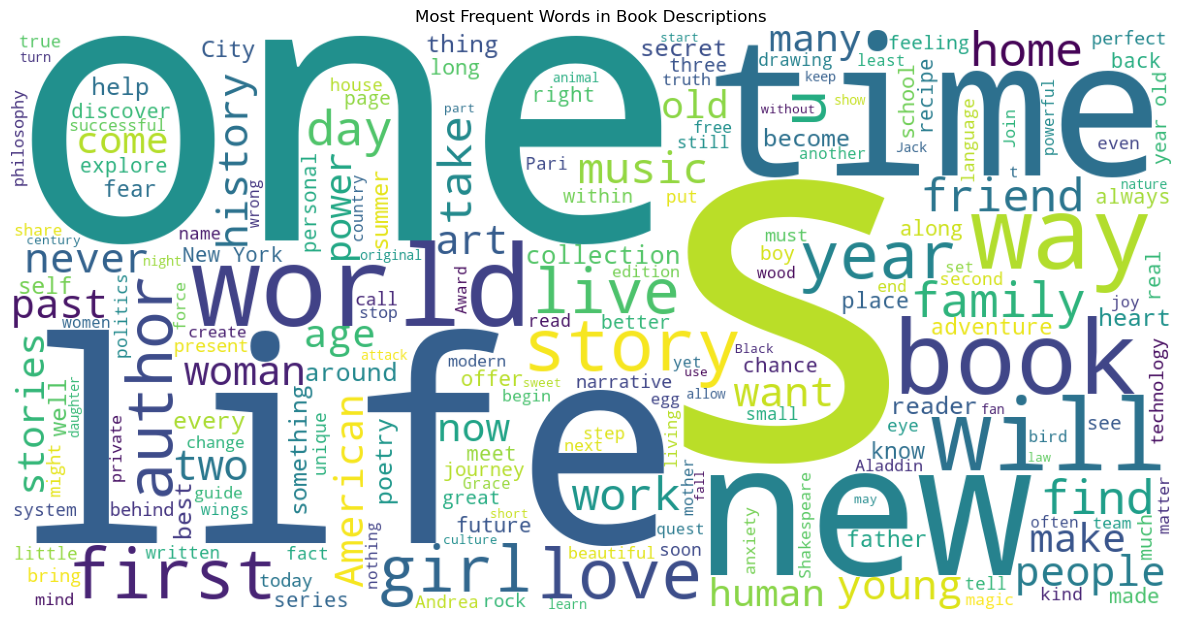

In [10]:
# ==========================================================
# Graph 7 : Word Cloud
# ==========================================================

text = " ".join(
    df["Product Description"].fillna("")
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Book Descriptions")

plt.show()

In [11]:
# ==========================================================
# Top 10 Most Expensive Books
# ==========================================================

df.nlargest(10,"Price")[["Title","Category","Price"]]

,Title,Category,Price
62,The Death of Humanity: and the Case for Life,Philosophy,58.11
94,Slow States of Collapse: Poems,Poetry,57.31
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25
37,The Past Never Ends,Mystery,56.50
38,The Pioneer Woman Cooks: Dinnertime: Comfort C...,Food and Drink,56.41
75,Masks and Shadows,Fantasy,56.40
39,The Secret of Dreadwillow Carse,Childrens,56.13
63,The Electric Pencil: Drawings from Inside Stat...,Nonfiction,56.06
34,Birdsong: A Story in Pictures,Childrens,54.64
15,Sapiens: A Brief History of Humankind,History,54.23


In [12]:
# ==========================================================
# Top 10 Best Value Books
# ==========================================================

df.nlargest(
    10,
    "value_score"
)[["Title","Rating","Price","value_score"]]

,Title,Rating,Price,value_score
85,Princess Between Worlds (Wide-Awake Princess #5),5,13.34,3.85
86,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",5,13.61,3.83
25,Sophie's World,5,15.94,3.63
41,Thirst,5,17.27,3.51
7,Set Me Free,5,17.46,3.50
29,The Four Agreements: A Practical Guide to Pers...,5,17.66,3.48
65,The Inefficiency Assassin: Time Management Tac...,5,20.59,3.23
74,Mama Tried: Traditional Italian Cooking for th...,4,14.02,3.04
47,Untitled Collection: Sabbath Poems 2014,4,14.27,3.02
91,#HigherSelfie: Wake Up Your Life. Free Your So...,5,23.11,3.01


In [13]:
# ==========================================================
# Category Summary
# ==========================================================

summary = (
    df.groupby("Category")
      .agg({
          "Price":"mean",
          "Rating":"mean",
          "Available Stock":"mean"
      })
)

summary

,Price,Rating,Available Stock
Category,,,
Add a comment,30.342000,2.600000,16.000000
Art,44.180000,4.000000,18.000000
Business,33.340000,4.000000,19.000000
Childrens,49.220000,1.666667,17.666667
Contemporary,31.770000,1.000000,16.000000
Default,26.847778,3.000000,18.111111
Fantasy,28.385000,3.250000,16.000000
Fiction,43.872000,3.800000,17.000000
Food and Drink,34.886000,2.200000,16.600000
